In [1]:
import os
os.chdir('../../../../../..')

In [25]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, get_isomers

In [15]:
qm9 = QM9Dataset(limit=50_000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf", "soap"])
df = qm9.load()
X=np.array(df["acsf_embedding"].to_list())

2026-05-19 11:14:33.455 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-19 11:14:33.874 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=50000, returned_rows=50000, sampling on columns=['num_atoms', 'gap'].
2026-05-19 11:14:33.875 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=50000).
2026-05-19 11:14:33.926 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-19 11:15:03.005 | SUCCESS  | src.datasets:add_acsf:1212 - Added ACSF embeddings and matrices.
2026-05-19 11:15:03.056 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-19 11:15:50.706 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-19 11:15:50.709 | INFO     |

# Hyphotesis 1
- how is ACSF different than SOAP?
 
 ACSF constructs a representation by explicitly separating 2-body (radial) and 3-body (angular) interactions using a set of discrete, binned symmetry functions (G2, G4, etc.). SOAP, conversely, represents the local environment as a continuous 3D atomic density (using Gaussians) and expands this density into spherical harmonics. The resulting power spectrum inherently couples radial and angular information and represents many-body correlations more smoothly.

 - Conformational changes that preserve local pairwise distances and simple bond angles, but alter the global 3D topology (many-body correlations), will exhibit proportionally larger and smoother relative distances in SOAP space compared to ACSF space.

In [33]:
from dscribe.kernels import REMatchKernel
import polars as pl
kernel = REMatchKernel(
    metric="linear", 
    alpha=0.1 
)


In [26]:
df_iso = get_isomers(df, pure_carbon = True, n=906)

2026-05-19 11:27:14.729 | INFO     | src.helper_functions:get_isomers:83 - Selected most frequent QM9 isomer group: formula=C9H14, available=470, returned=470.


In [34]:
acyclic_mols = df_iso.filter(pl.col("num_rings") == 0).head(5)
monocyclic_mols = df_iso.filter(pl.col("num_rings") == 1).head(5)
bicyclic_mols = df_iso.filter(pl.col("num_rings") == 2).head(5)

# 2. Verify we have enough molecules in each category
print(f"Found {acyclic_mols.height} acyclic, {monocyclic_mols.height} monocyclic, and {bicyclic_mols.height} bicyclic molecules.")

# 3. Combine into a curated dataset of exactly 15 molecules
df_curated = pl.concat([acyclic_mols, monocyclic_mols, bicyclic_mols])

# 4. Optional: Print the SMILES to see exactly what you are comparing
print("\nCurated Subset SMILES:")
for row in df_curated.iter_rows(named=True):
    print(f"Rings: {row['num_rings']} | SMILES: {row['canonical_smiles']}")

Found 0 acyclic, 5 monocyclic, and 5 bicyclic molecules.

Curated Subset SMILES:
Rings: 1 | SMILES: C#CCCCC1CCC1
Rings: 1 | SMILES: C#CCCCCC1CC1
Rings: 1 | SMILES: C1=C\CCC/C=C/CC/1
Rings: 1 | SMILES: C1=C\CCCCC\C=C/1
Rings: 1 | SMILES: C1=C\CCCC/C=C/C/1
Rings: 2 | SMILES: C1=C(CC2CC2)CCC1
Rings: 2 | SMILES: C1=C/[C@H]2C[C@H]2CCCC/1
Rings: 2 | SMILES: C1=C[C@@H]2CCCC[C@H]2C1
Rings: 2 | SMILES: C1CCC(=C2CCC2)C1
Rings: 2 | SMILES: C1=C(C2CCC2)CCC1


In [30]:
acsf_matrices = df_iso['acsf_matrix'].to_list()
kernel_matrix = kernel.create(acsf_matrices)

diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

np.fill_diagonal(dist_matrix, 0.0)
dist_matrix_acsf = (dist_matrix + dist_matrix.T) / 2.0

In [31]:
soap_matrices = df_iso['soap_matrix'].to_list()
kernel_matrix = kernel.create(soap_matrices)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix_soap = (dist_matrix + dist_matrix.T) / 2.0

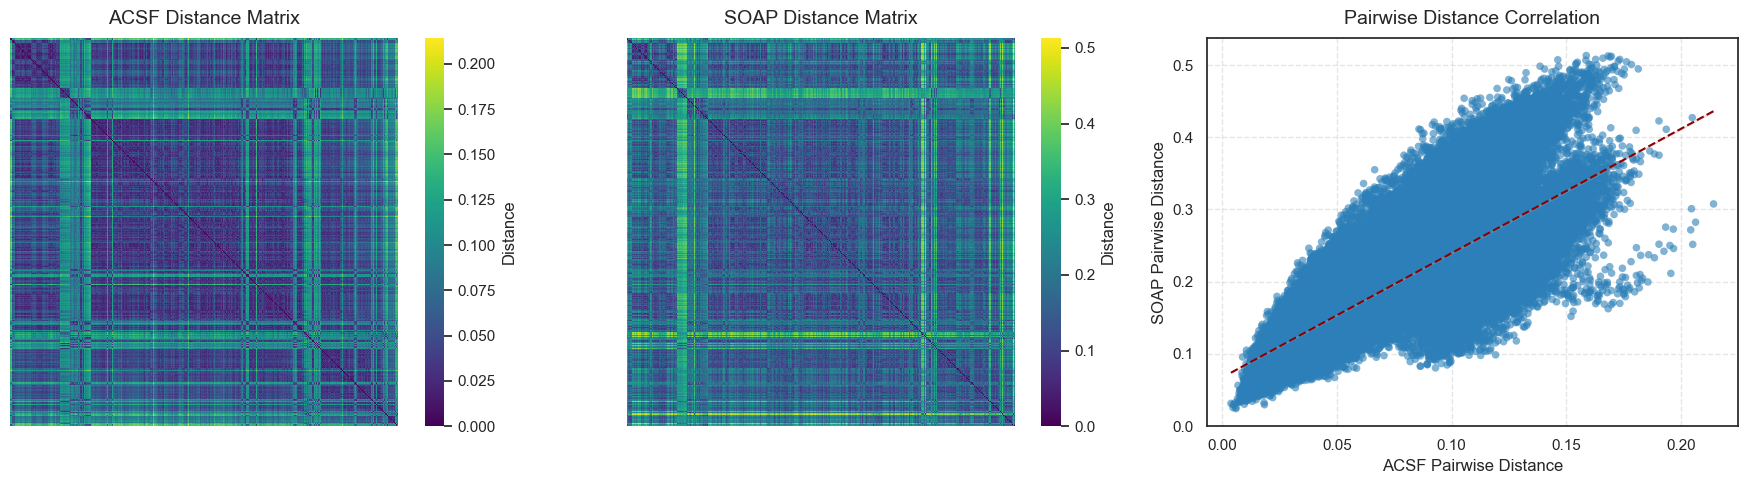

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
upper_tri_indices = np.triu_indices_from(dist_matrix_acsf, k=1)
acsf_pairwise = dist_matrix_acsf[upper_tri_indices]
soap_pairwise = dist_matrix_soap[upper_tri_indices]

# 2. Set up the plotting grid
fig = plt.figure(figsize=(18, 5))
sns.set_theme(style="white")

# --- Plot 1: ACSF Distance Heatmap ---
ax1 = fig.add_subplot(1, 3, 1)
# Using a consistent vmin and vmax across heatmaps can be helpful if they share 
# a similar scale, but ACSF and SOAP often have different dynamic ranges. 
# We let them scale naturally here but use the same colormap.
sns.heatmap(
    dist_matrix_acsf, 
    cmap="viridis", 
    square=True, 
    cbar_kws={'label': 'Distance'},
    xticklabels=False, 
    yticklabels=False,
    ax=ax1
)
ax1.set_title("ACSF Distance Matrix", fontsize=14, pad=10)

# --- Plot 2: SOAP Distance Heatmap ---
ax2 = fig.add_subplot(1, 3, 2)
sns.heatmap(
    dist_matrix_soap, 
    cmap="viridis", 
    square=True, 
    cbar_kws={'label': 'Distance'},
    xticklabels=False, 
    yticklabels=False,
    ax=ax2
)
ax2.set_title("SOAP Distance Matrix", fontsize=14, pad=10)

# --- Plot 3: Metric Space Correlation Scatter ---
ax3 = fig.add_subplot(1, 3, 3)
sns.scatterplot(
    x=acsf_pairwise, 
    y=soap_pairwise, 
    alpha=0.6, 
    edgecolor="none",
    s=30,
    color="#2c7fb8",
    ax=ax3
)

# Add a trend line to highlight non-linear topological scaling
sns.regplot(
    x=acsf_pairwise, 
    y=soap_pairwise, 
    scatter=False, 
    color="darkred", 
    line_kws={"linewidth": 1.5, "linestyle": "--"},
    ax=ax3
)

ax3.set_title("Pairwise Distance Correlation", fontsize=14, pad=10)
ax3.set_xlabel("ACSF Pairwise Distance", fontsize=12)
ax3.set_ylabel("SOAP Pairwise Distance", fontsize=12)
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()